Efecto del material interestelar
===

Alumno
---
Pedro G. Villegas

Docentes
---
J.P. Calderón & R. Gamen

Resumen
---
La radiación estelar sufre cambios al interactuar con el material interestelar que se encuentra entre la fuente y el observador. La extinción de la luz, producida por absorciones y dispersiones en el medio, es un efecto que depende de la longitud de onda, y como consecuencia de estos cambios en el espectro estelar, los índices de color de las estrellas se enrojecen, a la vez que disminuye el brillo estelar observado. El objetivo de esta práctica es familiarizarse con estos efectos a través de ejercicios con datos reales que obtendremos de bases de datos astronómicas.

Referencias
---
* [Práctica 04 (overleaf)](https://www.overleaf.com/read/yrtwdjtrhmmn)

---
      
Ejercicios
---
Objetivos:
    
    A- Calcular la distancia a 6 estrellas de la región de Cygnus:

HD 228452
HD 192557
HD 192605
TYC 2684-1684-1
HD 192164
HD 228119

    B- Caracterizar el medio interestelar
    
    C- El efecto del MIE

# A. Calcular la distancia a 6 estrellas de la región de Cygnus:

### 1. Busque las estrellas por identificador, obtenga el tipo espectral y las magnitudes aparentes ($m_V$ y $m_B$) de la base de datos de [Simbad](http://simbad.u-strasbg.fr/simbad/sim-fid).

In [1]:
from astroquery.simbad import Simbad
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Simbad.list_votable_fields() # Para saber qué podemos "consultar"

--NOTES--

1. The parameter filtername must correspond to an existing filter. Filters include: B,V,R,I,J,K.  They are checked by SIMBAD but not astroquery.simbad

2. Fields beginning with rvz display the data as it is in the database. Fields beginning with rv force the display as a radial velocity. Fields beginning with z force the display as a redshift

3. For each measurement catalog, the VOTable contains all fields of the first measurement. When applicable, the first measurement is the mean one. 

Available VOTABLE fields:

bibcodelist(y1-y2)
biblio
cel
cl.g
coo(opt)
coo_bibcode
coo_err_angle
coo_err_maja
coo_err_mina
coo_qual
coo_wavelength
coordinates
dec(opt)
dec_prec
diameter
dim
dim_angle
dim_bibcode
dim_incl
dim_majaxis
dim_minaxis
dim_qual
dim_wavelength
dimensions
distance
distance_result
einstein
fe_h
flux(filtername)
flux_bibcode(filtername)
flux_error(filtername)
flux_name(filtername)
flux_qual(filtername)
flux_system(filtername)
flux_unit(filtername)
fluxdata(filtername)

In [2]:
customSimbad = Simbad()
customSimbad.add_votable_fields ( 'ra', 'dec', 'sptype', 'sp_bibcode', 'flux(B)', 
                                 'flux(V)', 'flux_bibcode(B)', 'flux_bibcode(V)' ) #,'parallax')

table_results = customSimbad.query_objects ( [
    "HD 228452", 
    "HD 192557", 
    "HD 192605", 
    "TYC 2684-1684-1", 
    "HD 192164", 
    "HD 228119" 
] ).to_pandas()


table_results

,MAIN_ID,RA,DEC,RA_PREC,DEC_PREC,COO_ERR_MAJA,COO_ERR_MINA,COO_ERR_ANGLE,COO_QUAL,COO_WAVELENGTH,...,RA_2,DEC_2,SP_TYPE,SP_QUAL,SP_BIBCODE,SP_BIBCODE_2,FLUX_B,FLUX_V,FLUX_BIBCODE_B,FLUX_BIBCODE_V
0,HD 228452,20 13 57.4648,+35 24 11.048,14,14,0.0196,0.0287,90,A,O,...,20 13 57.4648,+35 24 11.048,B3V,C,,,10.430,9.770,,
1,HD 192557,20 14 13.9296,+35 21 42.012,14,14,0.0220,0.0274,90,A,O,...,20 14 13.9296,+35 21 42.012,F6V,C,,,8.080,7.590,,
2,HD 192605,20 14 25.2415,+35 37 20.339,14,14,0.0272,0.0326,90,A,O,...,20 14 25.2415,+35 37 20.339,B9V,C,,,8.680,8.710,,
3,TYC 2684-1684-1,20 16 28.1923,+35 45 49.569,14,14,0.0208,0.0263,90,A,O,...,20 16 28.1923,+35 45 49.569,G2V,D,,,11.620,10.920,2000A&A...355L..27H,2000A&A...355L..27H
4,HD 192164,20 12 18.3068,+34 51 10.696,14,14,0.0199,0.0243,90,A,O,...,20 12 18.3068,+34 51 10.696,K2V,C,,,9.290,7.800,,
5,HD 228119,20 10 47.9429,+35 08 05.943,14,14,0.0226,0.0304,90,A,O,...,20 10 47.9429,+35 08 05.943,A3V,C,,,9.904,9.758,2000A&A...355L..27H,2000A&A...355L..27H


In [3]:
table_results [[ 'MAIN_ID', 'SP_TYPE', 'FLUX_B', 'FLUX_V' ]]

,MAIN_ID,SP_TYPE,FLUX_B,FLUX_V
0,HD 228452,B3V,10.430,9.770
1,HD 192557,F6V,8.080,7.590
2,HD 192605,B9V,8.680,8.710
3,TYC 2684-1684-1,G2V,11.620,10.920
4,HD 192164,K2V,9.290,7.800
5,HD 228119,A3V,9.904,9.758


**2.** Obtenga las magnitudes absolutas $M_{V}$ y el índice de color intrínseco $(B−V)$ para cada estrella, según su tipo espectral de [Cox (2000, ver Tabla 15.7)](http://astronomiaestelarlp.pbworks.com/w/file/109924168/Allen%27s%20Astrophysical%20Quantities%20%284th%20Ed%29%20-%20Cox%2C%20A.N.%20%28ed.%29%20-%20Springer%20-%202001%20-%20ISBN%2097803879518.pdf). Será necesario realizar interpolaciones para algunos tipos espectrales no especificados en la bibliografía.

Interpolación de magnitudes absolutas según la tabla del Allen:

Para la primera:  
MV(B2)=-2.45, MV(B5)=-1.2
MV(B3) = MV(B2) - [MV(B2) - MV(B5)]/3  
MV(B3) = -2.45 - [-2.45 + 1.2]/3 = -0.416 - 2.45 = -2.03  

Segunda: MV(F5)=3.5, MV(F8)=4  
MV(F6) = MV(F5) + [MV(F5) - MV(F8)]/3  
MV(F6) = 3.5 + [3.5 - 4]/3 = 3.5 + 0.16 = 3.66

Tercera: MV(B8)=-0.25, MV(A0)=0.65  
MV(B9) = MV(B8) - [MV(B8) - MV(A0)]/2  
MV(B9) = -0.25 - [-0.25 - 0.65]/2 = -0.25 + 0.45 = 0.2  

Cuarta: MV(G2)=4.7  
Quinta: MV(K2)=6.4

Sexta: MV(A2)=1.3, MV(A5)=1.95  
MV(A3) = MV(A2) + [MV(A2) - MV(A5)]/3  
MV(A3) = 1.3 + [1.3 - 1.95]/3 = 1.3 + 0.216 = 1.51  

## -··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··-··

Interpolación de índices de color según el Allen:  
Primera: (B-V)(B2)=-0.24, (B-V)(B5)=-0.17  
(B-V)(B3) = (B-V)(B2) - [(B-V)(B2) - (B-V)(B5)]/3  
(B-V)(B3) = -0.24 - [-0.24 + 0.17]/3 = -0.24 + 0.023 = -0.217  

Segunda:  
(B-V)(F5)=0.44, (B-V)(F8)=0.52  
(B-V)(F6) = (B-V)(F5) + [(B-V)(F5) - (B-V)(F8)]/3  
(B-V)(F6) = 0.44 + [0.44 - 0.52]/3 = 0.44 + 0.026 = 0.466  

Tercera:  
(B-V)(B8)=-0.11, (B-V)(A0)=-0.02  
(B-V)(B9) = (B-V)(B8) - [(B-V)(B8) - (B-V)(A0)]/2  
(B-V)(B9) = -0.11 - [-0.11 + 0.02]/2 = -0.11 + 0.045 = -0.065  

Cuarta: (B-V)(G2)=0.63  
Quinta: (B-V)(K2)=0.91

Sexta:  
(B-V)(A2)=0.05, (B-V)(A5)=0.15  
(B-V)(A3) = (B-V)(A2) + [(B-V)(A2) - (B-V)(A5)]/3  
(B-V)(A3) = 0.05 + [0.05 - 0.15]/3 = 0.05 + 0.03 = 0.08  

In [ ]:
# Agrego las magnitudes absolutas obtenidas a la lista siguiente
table_results['MV'] = [ -2.03, 3.66, 0.2, 4.7, 6.4, 1.51]

# Lo mismo con el índices de color
table_results['(B-V)0'] = [ -0.21, 0.46, -0.06, 0.63, 0.91, 0.08]

table_results[[ 'MAIN_ID', 'SP_TYPE', 'FLUX_B', 'FLUX_V', 'MV', '(B-V)0' ]]

,MAIN_ID,SP_TYPE,FLUX_B,FLUX_V,MV,(B-V)0
0,HD 228452,B3V,10.430,9.770,-2.03,-0.21
1,HD 192557,F6V,8.080,7.590,3.66,0.46
2,HD 192605,B9V,8.680,8.710,0.20,-0.06
3,TYC 2684-1684-1,G2V,11.620,10.920,4.70,0.63
4,HD 192164,K2V,9.290,7.800,6.40,0.91
5,HD 228119,A3V,9.904,9.758,1.51,0.08


**3.** Deduzca el exceso de color $E(B−V)$ para cada estrella. Para esto, Calcule el índice de color $(B−V)$, a
partir de los datos obtenidos anteriormente y reste el color intrinseco $(B−V)_{0}$.

In [6]:
table_results['(B-V)'] = table_results['FLUX_B'] - table_results['FLUX_V']

table_results['E(B-V)'] = table_results['(B-V)'] - table_results['(B-V)0']

table_results[[ 'MAIN_ID', 'SP_TYPE', 'FLUX_B', 'FLUX_V', 'MV', '(B-V)0', '(B-V)', 'E(B-V)']]

,MAIN_ID,SP_TYPE,FLUX_B,FLUX_V,MV,(B-V)0,(B-V),E(B-V)
0,HD 228452,B3V,10.430,9.770,-2.03,-0.21,0.660,0.870
1,HD 192557,F6V,8.080,7.590,3.66,0.46,0.490,0.030
2,HD 192605,B9V,8.680,8.710,0.20,-0.06,-0.030,0.030
3,TYC 2684-1684-1,G2V,11.620,10.920,4.70,0.63,0.700,0.070
4,HD 192164,K2V,9.290,7.800,6.40,0.91,1.490,0.580
5,HD 228119,A3V,9.904,9.758,1.51,0.08,0.146,0.066


Suponiendo que la extinción interestelar en la banda $V$, expresada en magnitudes, sigue la relación:

$$A_{V} = R  E(B−V)$$

calcule el valor de la extinción para cada estrella.
Utilice el valor canónico para R (R = 3.1).

In [7]:
table_results['AV'] = 3.1 * table_results['E(B-V)']
table_results[[ 'MAIN_ID', 'SP_TYPE', 'FLUX_B', 'FLUX_V', 'MV', '(B-V)0', '(B-V)', 'E(B-V)', 'AV']]

,MAIN_ID,SP_TYPE,FLUX_B,FLUX_V,MV,(B-V)0,(B-V),E(B-V),AV
0,HD 228452,B3V,10.430,9.770,-2.03,-0.21,0.660,0.870,2.697000
1,HD 192557,F6V,8.080,7.590,3.66,0.46,0.490,0.030,0.092999
2,HD 192605,B9V,8.680,8.710,0.20,-0.06,-0.030,0.030,0.093001
3,TYC 2684-1684-1,G2V,11.620,10.920,4.70,0.63,0.700,0.070,0.216999
4,HD 192164,K2V,9.290,7.800,6.40,0.91,1.490,0.580,1.797999
5,HD 228119,A3V,9.904,9.758,1.51,0.08,0.146,0.066,0.204600


**4.** Calcule la distancia a cada estrella en parsecs. Utilice la fórmula del módulo de distancia:

$$V − M_{V} = −5 + 5 \log(d) + A_{V}$$




In [ ]:
table_results['distancia_tp04'] = 10**((table_results['FLUX_V'] - table_results['MV'] - table_results['AV'] + 5)/5)
# Al parecer esto me mata el kernel: np.exp(10,table_results['FLUX_V'] - table_results['MV'] - table_results['AV'] + 5)/5
table_results[['MAIN_ID','SP_TYPE','distancia_tp04']]

#Los resultados de Juan Pablo fueron:
#769.130770
#61.235063
#552.585955
#158.708480
#8.325306
#428.627599

,MAIN_ID,SP_TYPE,distancia_tp04
0,HD 228452,B3V,661.607144
1,HD 192557,F6V,58.532918
2,HD 192605,B9V,482.391717
3,TYC 2684-1684-1,G2V,158.708480
4,HD 192164,K2V,8.325306
5,HD 228119,A3V,406.144084


**5.** Compare las distancias calculadas con las determinadas a partir de las paralajes de Gaia. Comente cuáles pueden ser las causas de las diferencias. 

In [9]:
customSimbad.add_votable_fields ( 'distance' )
d_table = customSimbad.query_objects ( [ 
    "HD 228452", 
    "HD 192557", 
    "HD 192605",
    "TYC 2684-1684-1",
    "HD 192164",
    "HD 228119"
] ).to_pandas() 
d_table

,MAIN_ID,RA,DEC,RA_PREC,DEC_PREC,COO_ERR_MAJA,COO_ERR_MINA,COO_ERR_ANGLE,COO_QUAL,COO_WAVELENGTH,...,FLUX_V,FLUX_BIBCODE_B,FLUX_BIBCODE_V,Distance_distance,Distance_Q,Distance_unit,Distance_merr,Distance_perr,Distance_method,Distance_bibcode
0,HD 228452,20 13 57.4648,+35 24 11.048,14,14,0.0196,0.0287,90,A,O,...,9.770,,,1957.7134,,pc,-110.7633,110.7633,paral,2018yCat.1345....0G
1,HD 192557,20 14 13.9296,+35 21 42.012,14,14,0.0220,0.0274,90,A,O,...,7.590,,,58.4221,,pc,-0.1048,0.1048,paral,2018yCat.1345....0G
2,HD 192605,20 14 25.2415,+35 37 20.339,14,14,0.0272,0.0326,90,A,O,...,8.710,,,333.4334,,pc,-4.3026,4.3026,paral,2018yCat.1345....0G
3,TYC 2684-1684-1,20 16 28.1923,+35 45 49.569,14,14,0.0208,0.0263,90,A,O,...,10.920,2000A&A...355L..27H,2000A&A...355L..27H,134.9801,,pc,-0.5211,0.5211,paral,2018yCat.1345....0G
4,HD 192164,20 12 18.3068,+34 51 10.696,14,14,0.0199,0.0243,90,A,O,...,7.800,,,416.3197,,pc,-4.9223,4.9223,paral,2018yCat.1345....0G
5,HD 228119,20 10 47.9429,+35 08 05.943,14,14,0.0226,0.0304,90,A,O,...,9.758,2000A&A...355L..27H,2000A&A...355L..27H,324.4331,,pc,-3.6103,3.6103,paral,2018yCat.1345....0G


In [10]:
Pd_gaia = d_table[['MAIN_ID','Distance_distance']]
Pd_tp04 = table_results[['MAIN_ID','SP_TYPE','distancia_tp04']]

Pd_comparacion = Pd_gaia.merge ( Pd_tp04 )
Pd_comparacion['diff'] = Pd_comparacion['Distance_distance'] - Pd_comparacion['distancia_tp04']

Pd_comparacion

,MAIN_ID,Distance_distance,SP_TYPE,distancia_tp04,diff
0,HD 228452,1957.7134,B3V,661.607144,1296.106256
1,HD 192557,58.4221,F6V,58.532918,-0.110818
2,HD 192605,333.4334,B9V,482.391717,-148.958317
3,TYC 2684-1684-1,134.9801,G2V,158.708480,-23.728380
4,HD 192164,416.3197,K2V,8.325306,407.994394
5,HD 228119,324.4331,A3V,406.144084,-81.710984


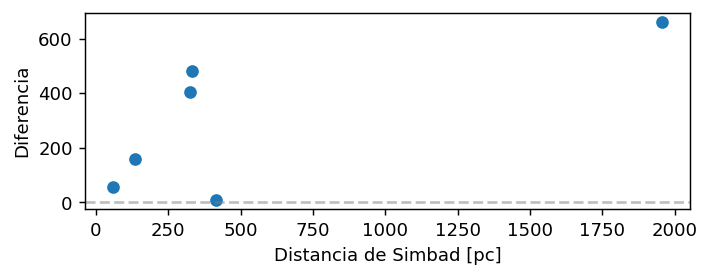

In [11]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (6, 2), dpi = 130 )

ax.scatter ( 'Distance_distance', 'distancia_tp04', data = Pd_comparacion )
ax.axhline ( y = 0, color = 'gray', ls = "--", alpha = 0.5 )

ax.set_xlabel ( 'Distancia de Simbad [pc]' )
ax.set_ylabel ( 'Diferencia')

plt.show()

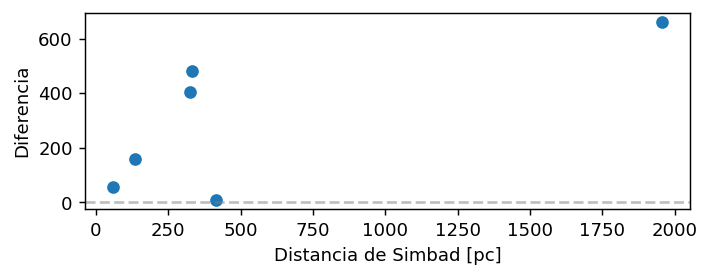

In [ ]:
# Original, no ejecutar
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (6, 2), dpi = 130 )

ax.scatter ( 'Distance_distance', 'distancia_tp04', data = Pd_comparacion )
ax.axhline ( y = 0, color = 'gray', ls = "--", alpha = 0.5 )

ax.set_xlabel ( 'Distancia de Simbad [pc]' )
ax.set_ylabel ( 'Diferencia')

plt.show()

**6.** Grafique en un diagrama color-magnitud las magnitudes y colores intrínsecos y observados. Indique con un vector cómo se desplazan las estrellas en dicho diagrama por efecto de la extinción interestelar (extinción y enrojecimiento).

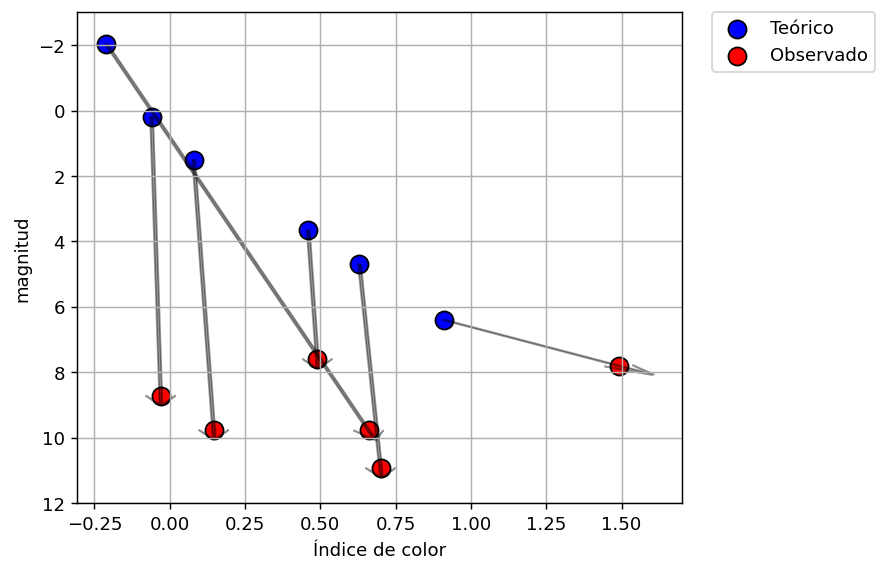

In [13]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (6, 5), dpi = 130 )

ax.scatter ( '(B-V)0', 'MV', data = table_results , 
             edgecolors = 'black', c = 'blue', s = 100, label = 'Teórico' )
ax.scatter ( '(B-V)', 'FLUX_V',data = table_results, 
             edgecolors = 'black', c = 'red', s = 100, label = 'Observado' )

for i in np.arange( len(table_results) ):
    x0 = table_results.loc[i,'(B-V)0']; y0 = table_results.loc[i,'MV']
    x = table_results.loc[i,'(B-V)']; y = table_results.loc[i,'FLUX_V']

    plt.arrow ( x0, y0, x-x0, y-y0, width = 0.01, color = "k", 
             head_width = 0.1, head_length = 0.3, overhang = 1, alpha = 0.4 )
      
ax.set_xlabel ( 'Índice de color' )
ax.set_ylabel ( 'magnitud')

plt.legend ( bbox_to_anchor = (1.05, 1), loc = 'upper left', borderaxespad = 0. )
plt.grid ( True )
plt.ylim ( [12, -3] )

plt.show()

# B. Caracterización  del  medio  interestelar

El medio interestelar actúa selectivamente sobre las longitudes de onda, cambiando el aspecto de la distribución espectral de energía SED (spectral energy distribution) de las estrellas. Todas las estrellas de un subtipo espectral tendrán los mismos índices de color intrínsecos ya que tienen la misma SED. Las diferencias de colores aparentes entre estrellas del mismo subtipo espectral son causadas por el medio interestelar. Para caracterizar el medio interestelar, conviene observar estrellas intrínsecamente brillantes, que son detectadas aún a grandes distancias.

**(a)** Seleccionaremos un conjunto de estrellas O4 y O5 de la base de datos 
[SIMBAD](http://simbad.u-strasbg.fr/simbad/sim-fsam), que tengan medidas de las magnitudes $U$, $B$ y $V$:
    
    sptypes = "O4" & Umag > 1 & Bmag > 1 & Vmag > 1 | sptypes = "O5" & Umag > 1 & Bmag > 1 & Vmag > 1

Esto es: Estrellas O4 con Umag, Bmag y Vmag distinto de cero (>1) o (|) estrellas O5 con Umag, Bmag y Vmag distinto de cero.

In [14]:
customSimbad = Simbad()

customSimbad.add_votable_fields ( 'flux(U)', 'flux(B)','flux(V)', 'sptype' )
result = customSimbad.query_criteria (
    'sptypes="O4V" & Umag>1 & Bmag>1 & Vmag>1 | sptypes="O5V" & Umag>1 & Bmag>1 & Vmag>1' )

result

MAIN_ID,RA,DEC,RA_PREC,DEC_PREC,COO_ERR_MAJA,COO_ERR_MINA,COO_ERR_ANGLE,COO_QUAL,COO_WAVELENGTH,COO_BIBCODE,FLUX_U,FLUX_B,FLUX_V,SP_TYPE,SP_QUAL,SP_BIBCODE
,"""h:m:s""","""d:m:s""",,,mas,mas,deg,,,,mag,mag,mag,,,
object,str13,str13,int16,int16,float32,float32,int16,str1,str1,object,float32,float32,float32,object,str1,object
V* V441 Pup,07 28 53.5787,-26 06 28.895,14,14,0.023,0.031,90,A,O,2018yCat.1345....0G,11.27,12.29,11.83,O5Ve,C,2016ApJS..224....4M
[MWP96] 189,01 33 33.75,+30 41 32.7,6,6,--,--,0,D,,1996AJ....111.1128M,20.82,22.46,21.97,O5V,C,2009ApJ...700.1847L
2MASS J05385364-6908116,05 38 53.641,-69 08 11.64,7,7,210.000,160.000,178,C,I,2003yCat.2246....0C,14.927,15.746,15.725,O5V,C,1999A&AS..137...21B
[MLD95] LMC 1-550,05 31 11.854,-71 04 10.10,7,7,110.000,110.000,90,C,I,2003yCat.2246....0C,12.207,12.941,13.231,O5V,C,2012A&A...547A..19K
SK -71 51,05 41 39.6169,-71 19 56.313,14,14,0.034,0.038,90,A,O,2018yCat.1345....0G,11.621,12.62,12.71,O4V,C,1986AJ.....92...48C
SK -70 60,05 04 40.7778,-70 15 34.500,14,14,0.032,0.034,90,A,O,2018yCat.1345....0G,12.609,13.646,13.914,O4V,C,1986AJ.....92...48C
AzV 388,01 05 39.5300,-72 29 26.938,14,14,0.038,0.028,90,A,O,2018yCat.1345....0G,12.79,13.86,14.12,O5V,C,2004MNRAS.353..601E
AzV 177,00 56 44.1039,-72 03 31.678,14,14,0.048,0.031,90,A,O,2018yCat.1345....0G,13.22,14.39,14.62,O4Vz,C,2013ApJ...763..101L


**(b)** Realizamos un gráfico color-color de las estrellas de la muestra ($B−V$) versus ($U−B$). Agregamos
    una secuencia principal de edad cero (ZAMS) y comentamos el resultado.

**(c)** Ajustamos la recta de enrojecimiento a partir de las estrellas de la muestra obtenida, encontrando el 
    valor de la pendiente en la siguiente expresión:

$$(U − B) = a (B − V) + b$$

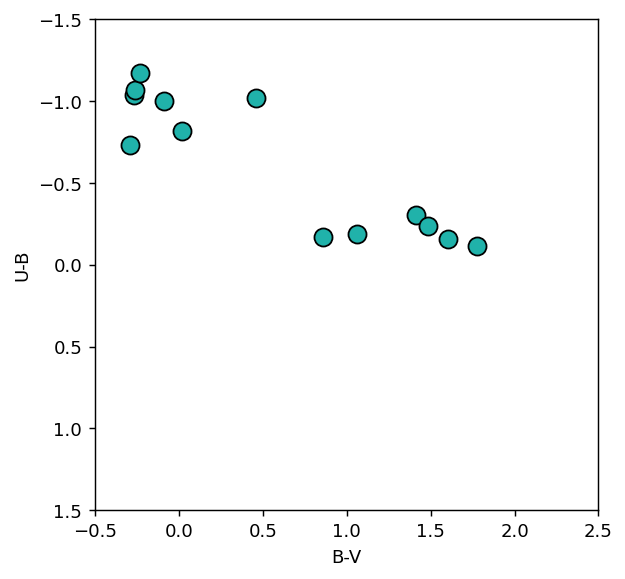

In [19]:
pd_ubv = result.to_pandas()
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )

X = pd_ubv['FLUX_B'] - pd_ubv['FLUX_V']
Y = pd_ubv['FLUX_U'] - pd_ubv['FLUX_B']

pd_ubv['B-V'] = X
pd_ubv['U-B'] = Y

ax.scatter ( X, Y, edgecolors = 'black', c = 'lightseagreen', s = 100, label = '' )

ax.set_ylim ( [1.5, -1.5] )
ax.set_xlim ( [-0.5, 2.5] )
ax.set_xlabel ( 'B-V' )
ax.set_ylabel ( 'U-B' )

plt.show()

In [21]:
pd_ubv

,MAIN_ID,RA,DEC,RA_PREC,DEC_PREC,COO_ERR_MAJA,COO_ERR_MINA,COO_ERR_ANGLE,COO_QUAL,COO_WAVELENGTH,COO_BIBCODE,FLUX_U,FLUX_B,FLUX_V,SP_TYPE,SP_QUAL,SP_BIBCODE,B-V,U-B
0,V* V441 Pup,07 28 53.5787,-26 06 28.895,14,14,0.0232,0.0312,90,A,O,2018yCat.1345....0G,11.270,12.290000,11.830000,O5Ve,C,2016ApJS..224....4M,0.460000,-1.020000
1,[MWP96] 189,01 33 33.75,+30 41 32.7,6,6,NaN,NaN,0,D,,1996AJ....111.1128M,20.820,22.459999,21.969999,O5V,C,2009ApJ...700.1847L,0.490000,-1.639999
2,2MASS J05385364-6908116,05 38 53.641,-69 08 11.64,7,7,210.0000,160.0000,178,C,I,2003yCat.2246....0C,14.927,15.746000,15.725000,O5V,C,1999A&AS..137...21B,0.021000,-0.819000
3,[MLD95] LMC 1-550,05 31 11.854,-71 04 10.10,7,7,110.0000,110.0000,90,C,I,2003yCat.2246....0C,12.207,12.941000,13.231000,O5V,C,2012A&A...547A..19K,-0.290000,-0.734000
4,SK -71 51,05 41 39.6169,-71 19 56.313,14,14,0.0337,0.0385,90,A,O,2018yCat.1345....0G,11.621,12.620000,12.710000,O4V,C,1986AJ.....92...48C,-0.090000,-0.999000
5,SK -70 60,05 04 40.7778,-70 15 34.500,14,14,0.0321,0.0342,90,A,O,2018yCat.1345....0G,12.609,13.646000,13.914000,O4V,C,1986AJ.....92...48C,-0.268000,-1.037000
6,AzV 388,01 05 39.5300,-72 29 26.938,14,14,0.0376,0.0284,90,A,O,2018yCat.1345....0G,12.790,13.860000,14.120000,O5V,C,2004MNRAS.353..601E,-0.260000,-1.070000
7,AzV 177,00 56 44.1039,-72 03 31.678,14,14,0.0482,0.0305,90,A,O,2018yCat.1345....0G,13.220,14.390000,14.620000,O4Vz,C,2013ApJ...763..101L,-0.230000,-1.170000
8,NGC 3603 22,11 15 10.071,-61 15 38.01,7,7,NaN,NaN,0,D,,2008AJ....135..878M,13.930,14.120000,13.060000,O5V,D,,1.059999,-0.190000
9,V* V662 Car,10 45 36.3216,-59 48 23.258,14,14,0.0250,0.0255,90,A,O,2018yCat.1345....0G,12.740,12.910000,12.050000,O5Vz+B0:V,C,2014ApJS..211...10S,0.860000,-0.170000


In [16]:
# Ajusto polinomio de grado 1  
coeff, cov = np.polyfit ( x = X, y = Y, deg = 1, cov = True )

pendiente = coeff[0]
ordenada = coeff[1]
std = np.sqrt ( np.diag(cov) )

pendiente, ordenada

(0.47829014532737596, -0.9650105283715757)

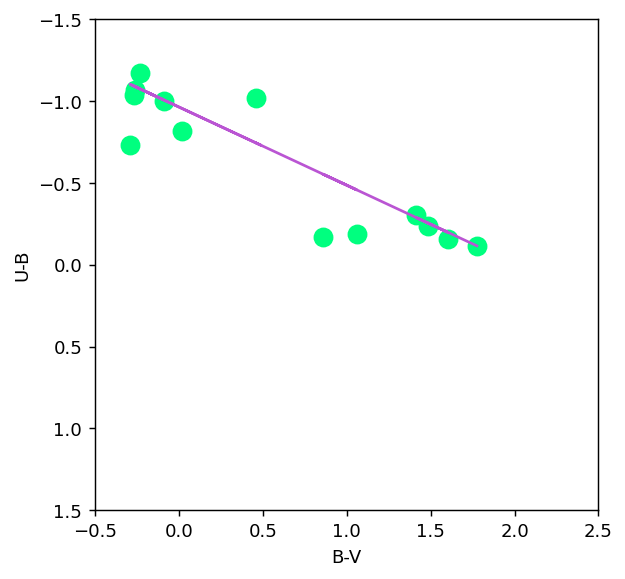

In [17]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )

ax.scatter ( X, Y, color = 'springgreen', s = 100, label = '' )
ax.plot ( X, pendiente*X + ordenada, color = 'mediumorchid' )

ax.set_ylim ( [1.5, -1.5] )
ax.set_xlim ( [-0.5, 2.5] )
ax.set_xlabel ( 'B-V' )
ax.set_ylabel ( 'U-B' )

plt.show()

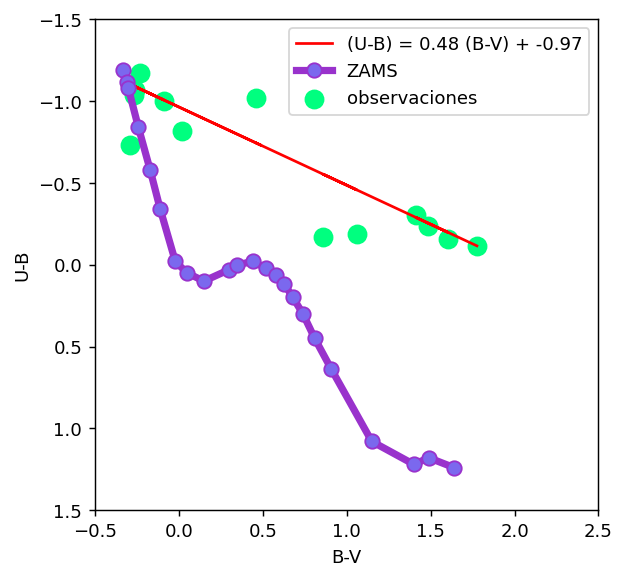

In [18]:
diagrama = pd.read_csv ( 'V.dat', sep = " ", comment = '#' )

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )

ax.scatter ( X, Y, color = 'springgreen', s = 100, label = 'observaciones' )
ax.plot ( X, pendiente*X + ordenada, color = 'red', label = '(U-B) = %.2f (B-V) + %.2f' %(pendiente,ordenada) )

ax.plot( 'B-V', 'U-B', data = diagrama, marker = 'o', 
         markerfacecolor = 'mediumslateblue', markersize = 8, color = 'darkorchid', linewidth = 4, label = "ZAMS" )

ax.set_ylim ( [1.5, -1.5] )
ax.set_xlim ( [-0.5, 2.5] )
ax.set_xlabel ( 'B-V' )
ax.set_ylabel ( 'U-B' )

plt.legend()
plt.show()

# C. El efecto de MIE

Podemos visualizar que la extinción que ejerce el medio interestelar sobre la radiación de las estrellas depende de la longitud de onda.

(a) Elija la estrella más extinguida de la lista anterior. 

(b) Obtenga (de Simbad) sus flujos en la mayor cantidad de filtros fotométricos posible.

(c) Busque las magnitudes absolutas calibradas para una estrella con el mismo tipo espectral.

(d) Diluya la magnitud absoluta por la distancia a dicha estrella.

(e) Compare las magnitudes corregidas por distancia y observada.

Comente: ¿Por qué las magnitudes comparadas no son iguales?¿Se verifica una dependencia con la longitud de onda?¿Qué pasaría si trato de determinar una temperatura con las magnitudes observadas?

In [22]:
from astroquery.simbad import Simbad
customSimbad = Simbad()
customSimbad.add_votable_fields ( 
    'sptype', 'sp_bibcode', 'flux(U)', 'flux(B)', 'flux(V)', 'flux(R)', 'flux(I)', 'flux(J)', 'flux(H)', 'flux(K)'
) #,'parallax')

# A modo de ejemplo: Efectivamente es la más extinguida
result_table = customSimbad.query_object ( "Cl* Westerlund 2 MSP 165" )
result_table

MAIN_ID,RA,DEC,RA_PREC,DEC_PREC,COO_ERR_MAJA,COO_ERR_MINA,COO_ERR_ANGLE,COO_QUAL,COO_WAVELENGTH,COO_BIBCODE,SP_TYPE,SP_QUAL,SP_BIBCODE,SP_BIBCODE_2,FLUX_U,FLUX_B,FLUX_V,FLUX_R,FLUX_I,FLUX_J,FLUX_H,FLUX_K
,"""h:m:s""","""d:m:s""",,,mas,mas,deg,,,,,,,,mag,mag,mag,mag,mag,mag,mag,mag
object,str13,str13,int16,int16,float32,float32,int16,str1,str1,object,object,str1,object,object,float32,float32,float32,float32,float32,float32,float32,float32
Cl* Westerlund 2 MSP 165,10 23 55.1750,-57 45 26.927,14,14,0.043,0.041,90,A,O,2018yCat.1345....0G,O4V,C,2013AJ....145..125V,2013AJ....145..125V,17.271,17.386,15.61,14.98,13.153,10.961,10.258,9.857


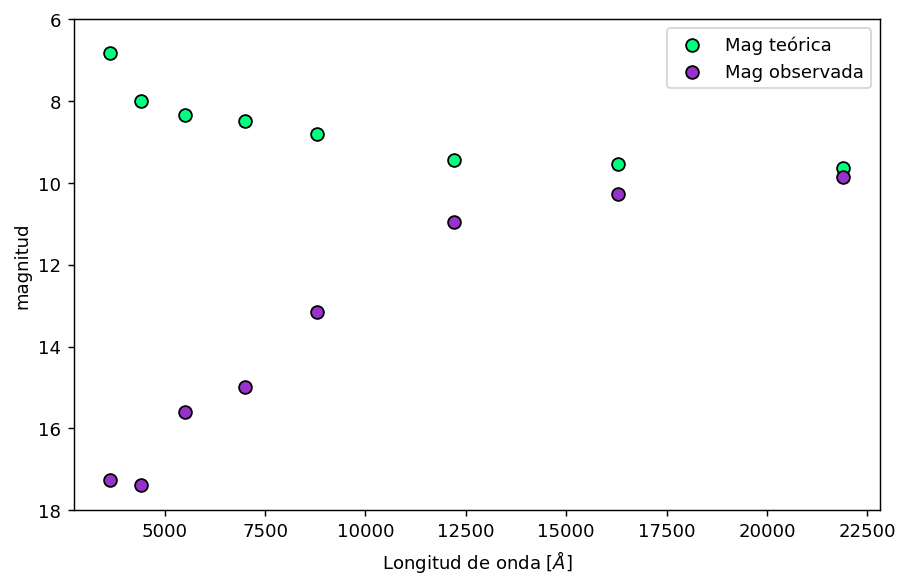

In [24]:
sed = pd.DataFrame()

# Agrego al _pandas_ las long. de onda media de los filtros: 
                #   U     B     V     R     I     J      H      K 
sed['lambda'] = [ 3650, 4400, 5500, 7000, 8800, 12200, 16300, 21900 ]

sed['M_abs'] =  [ -7.22, -6.03, -5.7, -5.55, -5.23, -4.60, -4.49, -4.39 ]

# Indicar la distancia en kpc
distancia = 6400.0 
sed['m_corr'] = sed['M_abs'] - 5 + 5 * np.log10(distancia)

sed['m_obs'] = [17.271, 17.386, 15.61, 14.98, 13.153, 10.961, 10.258, 9.857]
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (8, 5), dpi = 130 )

plt.scatter ( 'lambda', 'm_corr', data = sed, 
             edgecolors = 'black', c = 'springgreen', s = 50, label = 'Mag teórica' )
plt.scatter ( 'lambda', 'm_obs', data = sed,
             edgecolors = 'black', c = 'darkorchid', s = 50, label = 'Mag observada' )

plt.ylim ( [ 18, 6] )
plt.xlabel ( 'Longitud de onda [$\AA$]' )
plt.ylabel ( 'magnitud' )

plt.legend()
plt.show()